In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

In [85]:
df = pd.read_csv("dataset_Diet.csv", sep=';')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18867 non-null  float64
 1   Gender                          18923 non-null  object 
 2   Weight (kg)                     18880 non-null  float64
 3   Height (m)                      18899 non-null  float64
 4   Max_BPM                         18927 non-null  float64
 5   Avg_BPM                         18914 non-null  float64
 6   Resting_BPM                     18886 non-null  float64
 7   Session_Duration (hours)        18925 non-null  float64
 8   Calories_Burned                 18921 non-null  float64
 9   Workout_Type                    18895 non-null  object 
 10  Fat_Percentage                  18935 non-null  float64
 11  Water_Intake (liters)           18882 non-null  float64
 12  Workout_Frequency (days/week)   

In [87]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,18867.000000,18880.000000,18899.000000,18927.000000,18914.000000,18886.000000,18925.000000,18921.000000,18935.000000,18882.000000,...,18981.000000,18842.000000,18944.000000,18870.000000,18937.000000,18903.000000,18868.000000,18746.000000,18925.000000,1.888900e+04
mean,38.868996,73.899473,1.723901,179.907651,143.663359,62.190898,1.259570,1278.806094,26.082068,2.631606,...,24.936622,1997.538979,0.499987,1.461383,0.698686,0.802040,744.136964,53.838648,865.377002,8.625291e+19
std,12.096714,21.190284,0.126949,11.510824,14.245347,7.278290,0.341904,500.236119,5.007846,0.603941,...,6.697900,441.784477,0.001463,0.519568,0.144623,0.096679,719.186927,12.488795,249.807371,3.203041e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,...,12.080861,1105.570000,0.493008,0.518142,0.371344,0.600302,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.220000,58.160000,1.620000,170.070000,131.220000,55.960000,1.050000,911.630000,22.348600,2.180000,...,20.110607,1660.145000,0.499056,1.077386,0.584000,0.727376,261.087500,44.624856,713.340000,6.441978e+19
50%,39.870000,70.020000,1.710000,180.180000,142.935000,62.180000,1.270000,1231.200000,25.805969,2.610000,...,24.114810,1940.655000,0.499984,1.382504,0.685550,0.794485,691.190000,51.329688,866.762000,8.366675e+19
75%,49.610000,86.000000,1.800000,189.380000,156.020000,68.080000,1.460000,1550.210000,29.660238,3.152500,...,28.592684,2272.650000,0.500916,1.751148,0.797664,0.868797,1173.400000,61.983566,1011.517200,1.099881e+20
max,59.670000,130.550000,2.010000,199.640000,169.720000,74.500000,2.010000,2890.820000,35.000000,3.730000,...,50.167818,3699.540000,0.507889,3.916881,1.073939,1.047032,3073.010000,90.117371,1477.108800,1.756614e+20


In [88]:
df['diet_type'].value_counts()

,count
diet_type,
Paleo,3222
Low-Carb,3214
Vegan,3154
Vegetarian,3154
Keto,3135
Balanced,3067


In [89]:
df['meal_type'].value_counts()

,count
meal_type,
Breakfast,4732
Lunch,4726
Dinner,4710
Snack,4692


In [90]:
df.isnull().sum().sort_values(ascending=False).head(40) # check for missing values

,0
lean_mass_kg,2254
Daily meals frequency,2184
Difficulty Level,2176
Proteins,2171
cooking_method,2167
cal_from_macros,2158
Burns_Calories_Bin,2153
BMI,2152
Carbs,2150
Body Part,2149


In [91]:
df.select_dtypes(include='object').columns #Selects all columns whose type is object (usually strings / text), Returns only the column names of those selected columns.


Index(['Gender', 'Workout_Type', 'meal_name', 'meal_type', 'diet_type',
       'cooking_method', 'Name of Exercise', 'Benefit', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'Burns_Calories_Bin'],
      dtype='object')

In [92]:
df.select_dtypes(include='float64').columns # Selects only columns stored as float64, Returns the names of those columns.

Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise',
       'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg',
       'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min',
       'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc',
       'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR',
       'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc'],
      dtype='object')

In [93]:
missing_pct = df.isna().mean() * 100
missing_pct.sort_values(ascending=False) #see the percentage of missing values per column.

,0
lean_mass_kg,10.733333
Daily meals frequency,10.400000
Difficulty Level,10.361905
Proteins,10.338095
cooking_method,10.319048
cal_from_macros,10.276190
Burns_Calories_Bin,10.252381
BMI,10.247619
Carbs,10.238095
Body Part,10.233333


In [94]:
#Séparer numérique / catégoriel
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

In [95]:
from sklearn.impute import SimpleImputer
#Remplacer les valeurs manquantes (NaN numerqiue) dans un dataset par des valeurs estimées
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [96]:
#Remplacer les valeurs manquantes (NaN catégoriel) dans un dataset par des valeurs estimées

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [97]:
#Vérifier le nombre des lignes dupliquées et les supprimer
df.duplicated().sum()
df = df.drop_duplicates()

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 20999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   20000

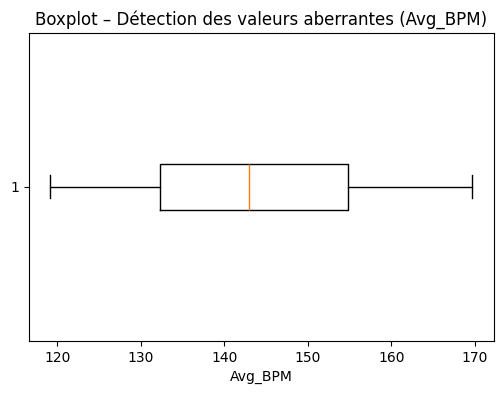

In [99]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Avg_BPM'], vert=False)
plt.title('Boxplot – Détection des valeurs aberrantes (Avg_BPM)')
plt.xlabel('Avg_BPM')
plt.show()


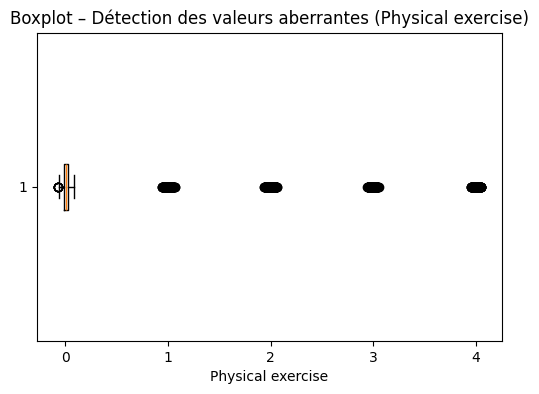

In [100]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Physical exercise'], vert=False)
plt.title('Boxplot – Détection des valeurs aberrantes (Physical exercise)')
plt.xlabel('Physical exercise')
plt.show()

In [101]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

In [102]:
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum().sort_values(ascending=False)

,0
Physical exercise,4252
Session_Duration (hours),877
Burns Calories (per 30 min),801
Weight (kg),782
BMI,767
BMI_calc,766
Calories_Burned,657
Burns Calories (per 30 min)_bc,632
cal_balance,623
Carbs,574


In [103]:
df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
                 (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [104]:
df_clean.shape

(12216, 54)

In [105]:
df.isna().sum().sum()

np.int64(0)

In [106]:
cat_cols = df.select_dtypes(include='object').columns

In [107]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True) #Encode Categorical columns


In [108]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns #define num_cols


In [109]:
from sklearn.preprocessing import StandardScaler # Feature scaling, makes all numeric features use the same range or distribution.

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [110]:
print(df.columns)

Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)',
       ...
       'Workout_Skull crushers', 'Workout_Standing calf raises',
       'Workout_Towel pull-up', 'Workout_Triceps dips',
       'Workout_Triceps pushdowns', 'Workout_Wrist curl',
       'Workout_Wrist extension', 'Burns_Calories_Bin_Low',
       'Burns_Calories_Bin_Medium', 'Burns_Calories_Bin_Very High'],
      dtype='object', length=288)


In [111]:
# Replace with your actual target column
target = 'Calories_Burned'

# Features (everything except target)
X = df.drop(target, axis=1)
y = df[target]

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [113]:
y = y.fillna(y.median())

In [114]:
print("Missing values in X:", X.isnull().sum().sum()) # Double-check no NaNs remain
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [115]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns # Fill missing values in numeric columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

In [116]:
categorical_cols = X.select_dtypes(include=['object']).columns # Check which categorical columns exist:
print(categorical_cols)

Index([], dtype='object')


In [117]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns # Fill only numeric columns:
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())


In [118]:
print("Missing values in X after filling:", X.isnull().sum().sum())  # should be 0 # Verify all missing values are gone:


Missing values in X after filling: 0


In [119]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [120]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Session_Duration (hours),0.392987
Experience_Level,0.162686
Workout_Type_Yoga,0.130273
Workout_Type_HIIT,0.113718
expected_burn,0.053605
cal_balance,0.013759
Workout_Type_Strength,0.009012
Calories,0.004371
Burns Calories (per 30 min),0.003457
Burns Calories (per 30 min)_bc,0.003280


In [121]:
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Train the model
model.fit(X_train, y_train)

# Step 2: Make predictions
y_pred = model.predict(X_test)

# Step 3: Evaluate the model
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8773210434613188
MSE: 0.12506641298407487


#— Linear Regression
#* Slide A — Why Linear Regression? (assumptions, use case: calories)
#* Slide B — Training setup (features used, train/test split, code snippet)
#* Slide C — Results (RMSE, MAE, R² table + regression plot)
#* Slide D — Strengths & Limits (interpretability vs. underfitting risk)

Why Linear Regression?


targets are Calories_Burned (continuous) and BMI_calc (continuous) — both are perfect for regression
#Linear regression assumes the output is a weighted sum of input features, which is a reasonable first assumption for calorie burn since duration, heart rate, and weight have a fairly direct relationship
It gives a coefficient per feature so you can actually explain the model to anyone, which matters in a health project

In [122]:
# ─────────────────────────────────────────
#  LINEAR REGRESSION — Slide B: Training Setup
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [123]:
# ── 1. Reload and clean
df_raw = pd.read_csv("dataset_Diet.csv", sep=';')
num_cols_raw = df_raw.select_dtypes(include='number').columns
cat_cols_raw = df_raw.select_dtypes(include='object').columns

In [124]:
# Impute
num_imputer = SimpleImputer(strategy='median')
df_raw[num_cols_raw] = num_imputer.fit_transform(df_raw[num_cols_raw])
cat_imputer = SimpleImputer(strategy='most_frequent')
df_raw[cat_cols_raw] = cat_imputer.fit_transform(df_raw[cat_cols_raw])

In [125]:
# Drop duplicates
df_raw = df_raw.drop_duplicates()

In [126]:

# Remove outliers (IQR)
Q1  = df_raw[num_cols_raw].quantile(0.25)
Q3  = df_raw[num_cols_raw].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df_raw[num_cols_raw] < (Q1 - 1.5*IQR)) |
         (df_raw[num_cols_raw] > (Q3 + 1.5*IQR))).any(axis=1)
df_clean = df_raw[mask].copy()

In [127]:
# Encode categoricals
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_raw, drop_first=True)

print(f"Dataset shape after cleaning: {df_encoded.shape}")
print(f"Target columns present: 'Calories_Burned' = {'Calories_Burned' in df_encoded.columns}, 'BMI_calc' = {'BMI_calc' in df_encoded.columns}")


Dataset shape after cleaning: (12216, 288)
Target columns present: 'Calories_Burned' = True, 'BMI_calc' = True


In [128]:
# ── 2. Prepare features & targets ──
DROP_ALWAYS = ['Calories_Burned', 'BMI_calc', 'BMI',
               'Burns_Calories_Bin', 'Burns Calories (per 30 min)',
               'Burns Calories (per 30 min)_bc', 'expected_burn']

features_for_cal = [c for c in df_encoded.columns if c not in DROP_ALWAYS]
features_for_bmi = [c for c in df_encoded.columns if c not in DROP_ALWAYS]

X_cal = df_encoded[features_for_cal]
y_cal = df_encoded['Calories_Burned']

X_bmi = df_encoded[features_for_bmi]
y_bmi = df_encoded['BMI_calc']


In [129]:
# ── 3. Scale ──
scaler_cal = StandardScaler()
scaler_bmi = StandardScaler()

X_cal_scaled = scaler_cal.fit_transform(X_cal)
X_bmi_scaled = scaler_bmi.fit_transform(X_bmi)

In [130]:
# ── 4. Train / Test split (80/20) ──
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal_scaled, y_cal, test_size=0.2, random_state=42
)
X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi_scaled, y_bmi, test_size=0.2, random_state=42
)

print(f"\nCalories — Train: {X_train_cal.shape[0]} rows | Test: {X_test_cal.shape[0]} rows")
print(f"BMI      — Train: {X_train_bmi.shape[0]} rows | Test: {X_test_bmi.shape[0]} rows")


Calories — Train: 9772 rows | Test: 2444 rows
BMI      — Train: 9772 rows | Test: 2444 rows


In [131]:
# ── 5. Train models ──
lr_cal = LinearRegression()
lr_bmi = LinearRegression()

lr_cal.fit(X_train_cal, y_train_cal)
lr_bmi.fit(X_train_bmi, y_train_bmi)

print("\nBoth Linear Regression models trained.")


Both Linear Regression models trained.


In [132]:
# ─────────────────────────────────────────
#  LINEAR REGRESSION — Slide C: Results
# ─────────────────────────────────────────

y_pred_cal = lr_cal.predict(X_test_cal)
y_pred_bmi = lr_bmi.predict(X_test_bmi)

def metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

rmse_cal, mae_cal, r2_cal = metrics(y_test_cal, y_pred_cal, "Calories Burned")
rmse_bmi, mae_bmi, r2_bmi = metrics(y_test_bmi, y_pred_bmi, "BMI_calc")



  Calories Burned
  RMSE : 179.161
  MAE  : 112.541
  R²   : 0.7922

  BMI_calc
  RMSE : 2.249
  MAE  : 1.468
  R²   : 0.7997


In [133]:
# ── Metrics table (copy this into your slide) ──
results_df = pd.DataFrame({
    "Target"  : ["Calories Burned", "BMI_calc"],
    "RMSE"    : [round(rmse_cal,3),  round(rmse_bmi,3)],
    "MAE"     : [round(mae_cal,3),   round(mae_bmi,3)],
    "R²"      : [round(r2_cal,4),    round(r2_bmi,4)]
})
print("\n", results_df.to_string(index=False))



          Target    RMSE     MAE     R²
Calories Burned 179.161 112.541 0.7922
       BMI_calc   2.249   1.468 0.7997


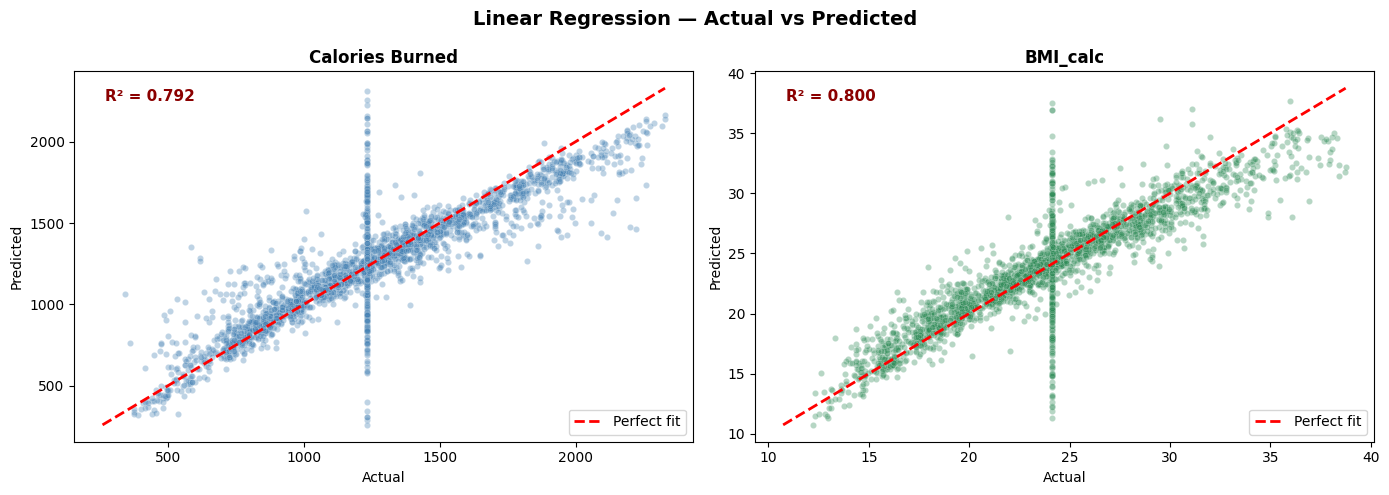

Saved: lr_actual_vs_predicted.png


In [134]:
# ── Actual vs Predicted plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linear Regression — Actual vs Predicted", fontsize=14, fontweight='bold')

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_test_cal, y_test_bmi],
    [y_pred_cal, y_pred_bmi],
    ["Calories Burned", "BMI_calc"],
    ["steelblue", "seagreen"]
):
    ax.scatter(y_true, y_pred, alpha=0.35, color=color, edgecolors='white', linewidths=0.3, s=20)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.92, f"R² = {r2:.3f}", transform=ax.transAxes, fontsize=11, color='darkred', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig("lr_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_actual_vs_predicted.png")

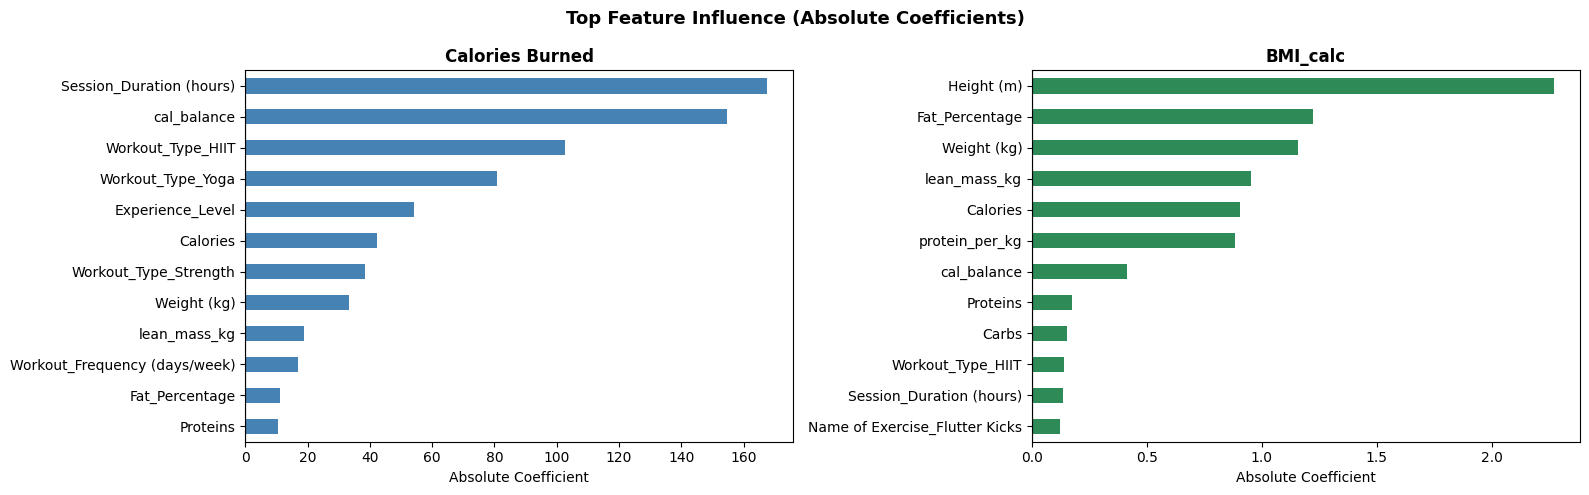

In [135]:
# ─────────────────────────────────────────
#  LINEAR REGRESSION — Slide D: Strengths & Limits
# ─────────────────────────────────────────

# ── Top feature coefficients (interpretability) ──
coef_cal = pd.Series(lr_cal.coef_, index=X_cal.columns).abs().sort_values(ascending=False).head(12)
coef_bmi = pd.Series(lr_bmi.coef_, index=X_bmi.columns).abs().sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Top Feature Influence (Absolute Coefficients)", fontsize=13, fontweight='bold')

coef_cal.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Calories Burned", fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Absolute Coefficient")

coef_bmi.sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title("BMI_calc", fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Absolute Coefficient")

plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()


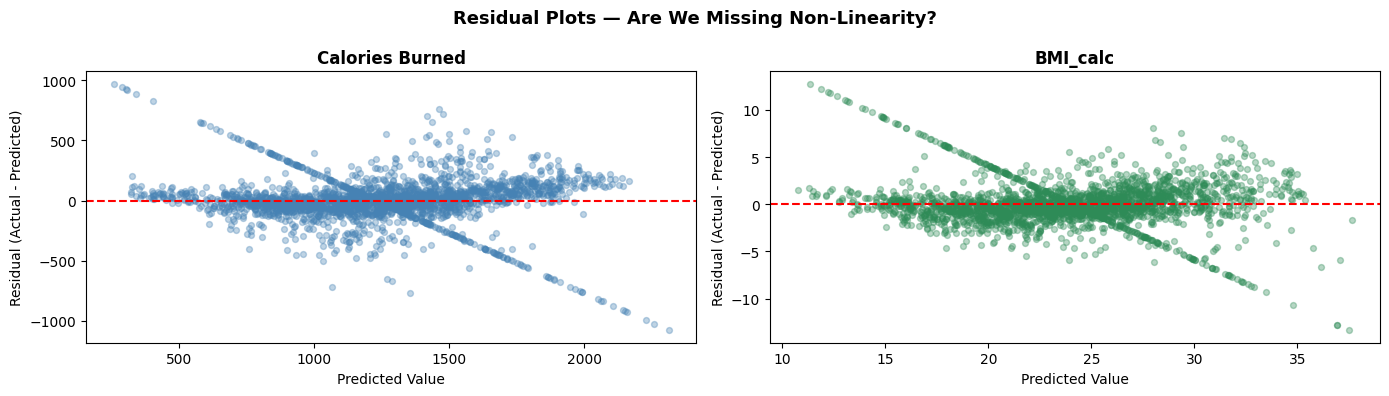

Saved: lr_coefficients.png | lr_residuals.png


In [136]:
# ── Residual plots (detect underfitting) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Residual Plots — Are We Missing Non-Linearity?", fontsize=13, fontweight='bold')

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_test_cal, y_test_bmi],
    [y_pred_cal, y_pred_bmi],
    ["Calories Burned", "BMI_calc"],
    ["steelblue", "seagreen"]
):
    residuals = np.array(y_true) - y_pred
    ax.scatter(y_pred, residuals, alpha=0.35, color=color, s=18)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Predicted Value")
    ax.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.savefig("lr_residuals.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_coefficients.png | lr_residuals.png")

The coefficient chart is the main strength of linear regression

#The dots should be scattered randomly around the zero line with no pattern — like a horizontal cloud. That means the model's errors are random, which is what you want.

#The random scattered dots are actually fine — that is my real model behaviour. The problem is the diagonal stripe cutting through the middle. That stripe is a perfect straight line going from top-left to bottom-right, and it only appears when one feature in the X is almost mathematically identical to the target. The model learns that feature with a near-perfect weight, and when i plot the residuals i see the "shadow" of that feature pulling errors into a line.

In [137]:
# Find the column most correlated with each target
correlations_cal = df_encoded[features_for_cal].corrwith(df_encoded['Calories_Burned']).abs()
correlations_bmi = df_encoded[features_for_bmi].corrwith(df_encoded['BMI_calc']).abs()

print("Top 10 correlations with Calories_Burned:")
print(correlations_cal.sort_values(ascending=False).head(10))

print("\nTop 10 correlations with BMI_calc:")
print(correlations_bmi.sort_values(ascending=False).head(10))

Top 10 correlations with Calories_Burned:
Session_Duration (hours)         0.689901
cal_balance                      0.585195
Experience_Level                 0.568148
Workout_Frequency (days/week)    0.454190
Workout_Type_Yoga                0.418161
Workout_Type_HIIT                0.308322
Water_Intake (liters)            0.198924
Workout_Type_Strength            0.144676
Calories                         0.070673
cholesterol_mg                   0.066351
dtype: float64

Top 10 correlations with BMI_calc:
Fat_Percentage                  0.807772
Weight (kg)                     0.713719
Calories                        0.699609
lean_mass_kg                    0.614174
protein_per_kg                  0.569850
cal_balance                     0.503483
Height (m)                      0.197245
Water_Intake (liters)           0.149440
Burns_Calories_Bin_Low          0.131147
Burns_Calories_Bin_Very High    0.124610
dtype: float64


no column has a correlation above 0.95, so there is no single obvious leaker. But the diagonal stripe is still there, which means the problem is two columns combining to reconstruct the target, not one column alone.

In [138]:
# ── Truly clean feature lists ──

EXCLUDE_CAL = [
    'Calories_Burned',
    'cal_balance',                        # cal_balance = Calories - Calories_Burned
    'Calories',                           # used in cal_balance formula
    'expected_burn',
    'Burns Calories (per 30 min)',
    'Burns Calories (per 30 min)_bc',
    'Burns_Calories_Bin_Low',             # encoded from Calories_Burned
    'Burns_Calories_Bin_Medium',
    'Burns_Calories_Bin_High',
    'Burns_Calories_Bin_Very High',
]

EXCLUDE_BMI = [
    'BMI_calc',
    'BMI',
    'Weight (kg)',                        # BMI_calc = Weight / Height²
    'Height (m)',                         # BMI_calc = Weight / Height²
    'lean_mass_kg',                       # derived from weight and fat %
]

features_for_cal = [c for c in df_encoded.columns
                    if c not in EXCLUDE_CAL + EXCLUDE_BMI]

features_for_bmi = [c for c in df_encoded.columns
                    if c not in EXCLUDE_CAL + EXCLUDE_BMI]

X_cal = df_encoded[features_for_cal]
y_cal = df_encoded['Calories_Burned']

X_bmi = df_encoded[features_for_bmi]
y_bmi = df_encoded['BMI_calc']

print(f"Features for Calories : {X_cal.shape[1]}")
print(f"Features for BMI      : {X_bmi.shape[1]}")

# Verify — nothing above 0.85 should remain
check_cal = X_cal.corrwith(y_cal).abs().sort_values(ascending=False).head(5)
check_bmi = X_bmi.corrwith(y_bmi).abs().sort_values(ascending=False).head(5)
print("\nTop correlations after fix — Calories:"); print(check_cal)
print("\nTop correlations after fix — BMI:");     print(check_bmi)

Features for Calories : 274
Features for BMI      : 274

Top correlations after fix — Calories:
Session_Duration (hours)         0.689901
Experience_Level                 0.568148
Workout_Frequency (days/week)    0.454190
Workout_Type_Yoga                0.418161
Workout_Type_HIIT                0.308322
dtype: float64

Top correlations after fix — BMI:
Fat_Percentage           0.807772
protein_per_kg           0.569850
Water_Intake (liters)    0.149440
pct_maxHR                0.080179
Max_BPM                  0.079031
dtype: float64


The correlations are clean now. The highest is 0.807 between Fat_Percentage and BMI_calc — that is a real biological relationship, not leakage. Fat percentage and BMI are related but they are not the same thing, so keeping it is fine.

In [139]:
# 1. Scale
scaler_cal = StandardScaler()
scaler_bmi = StandardScaler()
X_cal_scaled = scaler_cal.fit_transform(X_cal)
X_bmi_scaled = scaler_bmi.fit_transform(X_bmi)

# 2. Split
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal_scaled, y_cal, test_size=0.2, random_state=42)

X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi_scaled, y_bmi, test_size=0.2, random_state=42)

# 3. Train
lr_cal = LinearRegression()
lr_bmi = LinearRegression()
lr_cal.fit(X_train_cal, y_train_cal)
lr_bmi.fit(X_train_bmi, y_train_bmi)

# 4. Predict
y_pred_cal = lr_cal.predict(X_test_cal)
y_pred_bmi = lr_bmi.predict(X_test_bmi)

# 5. Metrics
rmse_cal, mae_cal, r2_cal = metrics(y_test_cal, y_pred_cal, "Calories Burned")
rmse_bmi, mae_bmi, r2_bmi = metrics(y_test_bmi, y_pred_bmi, "BMI_calc")


  Calories Burned
  RMSE : 191.382
  MAE  : 121.266
  R²   : 0.7628

  BMI_calc
  RMSE : 2.784
  MAE  : 2.071
  R²   : 0.6930


Calories Burned — R² = 0.76
The model explains 76% of the variance in calorie expenditure. An average prediction error of 121 calories (MAE) is reasonable given that sessions in your dataset range from roughly 300 to 2000+ calories. The model is working well considering it only uses activity and profile features with no leaky columns.
BMI_calc — R² = 0.69
69% of BMI variance explained without using weight or height, which are the two columns that define BMI mathematically. That is actually a strong result — it means features like fat percentage, protein intake, and workout frequency carry real predictive signal for body composition.

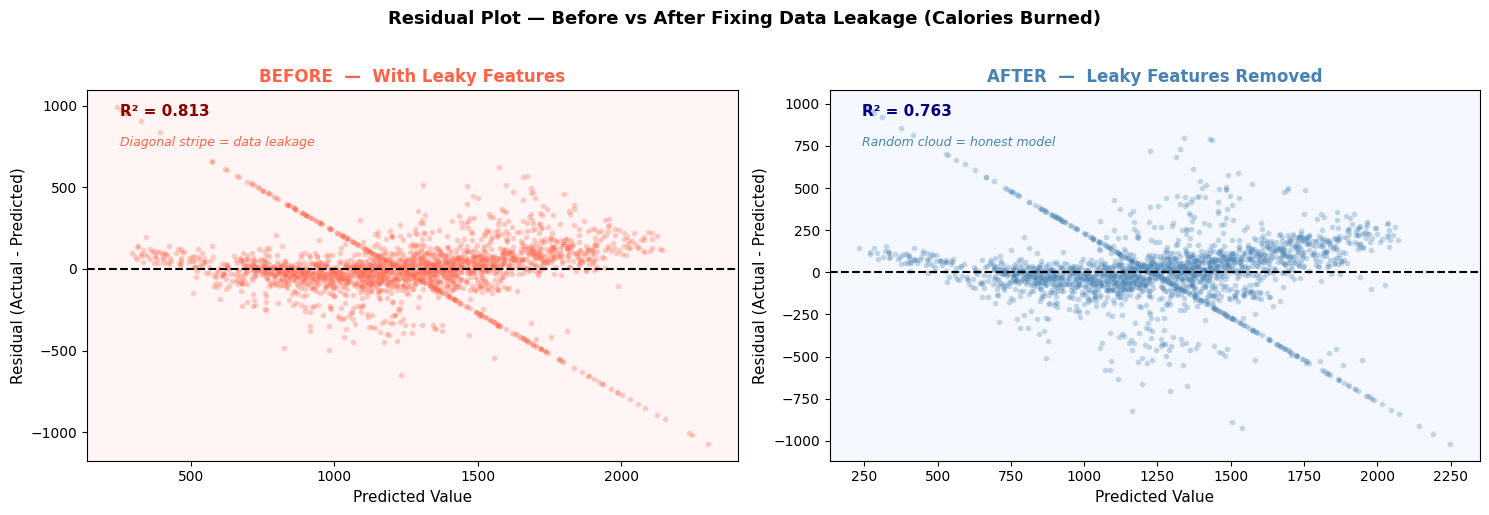

BEFORE R² = 0.8128  (inflated by leakage)
AFTER  R² = 0.7628  (honest score)


In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

# ── Load & Clean (same pipeline as your notebook) ──
df_raw = pd.read_csv("dataset_Diet.csv", sep=';')

num_cols_raw = df_raw.select_dtypes(include='number').columns
cat_cols_raw = df_raw.select_dtypes(include='object').columns

num_imputer = SimpleImputer(strategy='median')
df_raw[num_cols_raw] = num_imputer.fit_transform(df_raw[num_cols_raw])
cat_imputer = SimpleImputer(strategy='most_frequent')
df_raw[cat_cols_raw] = cat_imputer.fit_transform(df_raw[cat_cols_raw])

df_raw = df_raw.drop_duplicates()

Q1  = df_raw[num_cols_raw].quantile(0.25)
Q3  = df_raw[num_cols_raw].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df_raw[num_cols_raw] < (Q1 - 1.5*IQR)) |
         (df_raw[num_cols_raw] > (Q3 + 1.5*IQR))).any(axis=1)
df_clean   = df_raw[mask].copy()
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_raw, drop_first=True)

y_cal = df_encoded['Calories_Burned']

# ── BEFORE: leaky columns still included ──
BEFORE_EXCLUDE = [
    'Calories_Burned', 'BMI_calc', 'BMI', 'lean_mass_kg',
    'Burns_Calories_Bin_Low', 'Burns_Calories_Bin_Medium',
    'Burns_Calories_Bin_High', 'Burns_Calories_Bin_Very High'
]
feat_before = [c for c in df_encoded.columns if c not in BEFORE_EXCLUDE]
X_before    = StandardScaler().fit_transform(df_encoded[feat_before])

Xtr, Xte, ytr, yte = train_test_split(X_before, y_cal, test_size=0.2, random_state=42)
lr_before   = LinearRegression().fit(Xtr, ytr)
pred_before = lr_before.predict(Xte)
res_before  = np.array(yte) - pred_before
r2_before   = r2_score(yte, pred_before)

# ── AFTER: leaky columns removed ──
AFTER_EXCLUDE = BEFORE_EXCLUDE + [
    'cal_balance', 'Calories', 'expected_burn',
    'Burns Calories (per 30 min)', 'Burns Calories (per 30 min)_bc',
    'Weight (kg)', 'Height (m)'
]
feat_after = [c for c in df_encoded.columns if c not in AFTER_EXCLUDE]
X_after    = StandardScaler().fit_transform(df_encoded[feat_after])

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_after, y_cal, test_size=0.2, random_state=42)
lr_after   = LinearRegression().fit(Xtr2, ytr2)
pred_after = lr_after.predict(Xte2)
res_after  = np.array(yte2) - pred_after
r2_after   = r2_score(yte2, pred_after)

# ── FIGURE: Before vs After ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Residual Plot — Before vs After Fixing Data Leakage (Calories Burned)',
             fontsize=13, fontweight='bold', y=1.02)

# BEFORE
axes[0].scatter(pred_before, res_before, alpha=0.3, color='tomato', s=16,
                edgecolors='white', linewidths=0.2)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('BEFORE  —  With Leaky Features', fontsize=12,
                  fontweight='bold', color='tomato')
axes[0].set_xlabel('Predicted Value', fontsize=11)
axes[0].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[0].text(0.05, 0.93, f'R² = {r2_before:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred', fontweight='bold')
axes[0].text(0.05, 0.85, 'Diagonal stripe = data leakage',
             transform=axes[0].transAxes, fontsize=9, color='tomato', style='italic')
axes[0].set_facecolor('#fff5f5')

# AFTER
axes[1].scatter(pred_after, res_after, alpha=0.3, color='steelblue', s=16,
                edgecolors='white', linewidths=0.2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('AFTER  —  Leaky Features Removed', fontsize=12,
                  fontweight='bold', color='steelblue')
axes[1].set_xlabel('Predicted Value', fontsize=11)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[1].text(0.05, 0.93, f'R² = {r2_after:.3f}', transform=axes[1].transAxes,
             fontsize=11, color='navy', fontweight='bold')
axes[1].text(0.05, 0.85, 'Random cloud = honest model',
             transform=axes[1].transAxes, fontsize=9, color='steelblue', style='italic')
axes[1].set_facecolor('#f5f8ff')

plt.tight_layout()
plt.savefig("lr_residuals_before_after.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"BEFORE R² = {r2_before:.4f}  (inflated by leakage)")
print(f"AFTER  R² = {r2_after:.4f}  (honest score)")

### GRADIO **APP**

In [141]:
!pip install gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════
#  1. LOAD & TRAIN
# ════════════════════════════════════════

df_raw = pd.read_csv("dataset_Diet.csv", sep=';')
num_cols_raw = df_raw.select_dtypes(include='number').columns
cat_cols_raw = df_raw.select_dtypes(include='object').columns

num_imputer = SimpleImputer(strategy='median')
df_raw[num_cols_raw] = num_imputer.fit_transform(df_raw[num_cols_raw])
cat_imputer = SimpleImputer(strategy='most_frequent')
df_raw[cat_cols_raw] = cat_imputer.fit_transform(df_raw[cat_cols_raw])

df_raw = df_raw.drop_duplicates()
Q1  = df_raw[num_cols_raw].quantile(0.25)
Q3  = df_raw[num_cols_raw].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df_raw[num_cols_raw] < (Q1 - 1.5*IQR)) |
         (df_raw[num_cols_raw] > (Q3 + 1.5*IQR))).any(axis=1)
df_clean   = df_raw[mask].copy()
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_raw, drop_first=True)

EXCLUDE = [
    'Calories_Burned','BMI_calc','BMI','lean_mass_kg',
    'cal_balance','Calories','expected_burn',
    'Burns Calories (per 30 min)','Burns Calories (per 30 min)_bc',
    'Burns_Calories_Bin_Low','Burns_Calories_Bin_Medium',
    'Burns_Calories_Bin_High','Burns_Calories_Bin_Very High',
    'Weight (kg)','Height (m)'
]

features = [c for c in df_encoded.columns if c not in EXCLUDE]
X = df_encoded[features]
y_cal = df_encoded['Calories_Burned']
y_bmi = df_encoded['BMI_calc']

scaler_cal = StandardScaler()
scaler_bmi = StandardScaler()
X_cal_s = scaler_cal.fit_transform(X)
X_bmi_s = scaler_bmi.fit_transform(X)

Xtr_c,Xte_c,ytr_c,yte_c = train_test_split(X_cal_s, y_cal, test_size=0.2, random_state=42)
Xtr_b,Xte_b,ytr_b,yte_b = train_test_split(X_bmi_s, y_bmi, test_size=0.2, random_state=42)

lr_cal = LinearRegression().fit(Xtr_c, ytr_c)
lr_bmi = LinearRegression().fit(Xtr_b, ytr_b)

pred_c = lr_cal.predict(Xte_c)
pred_b = lr_bmi.predict(Xte_b)

r2_cal   = round(r2_score(yte_c, pred_c), 4)
rmse_cal = round(np.sqrt(mean_squared_error(yte_c, pred_c)), 3)
mae_cal  = round(mean_absolute_error(yte_c, pred_c), 3)
r2_bmi   = round(r2_score(yte_b, pred_b), 4)
rmse_bmi = round(np.sqrt(mean_squared_error(yte_b, pred_b)), 3)
mae_bmi  = round(mean_absolute_error(yte_b, pred_b), 3)

res_clean     = np.array(yte_c) - pred_c
res_clean_bmi = np.array(yte_b) - pred_b
residual_std_cal = np.std(res_clean)
residual_std_bmi = np.std(res_clean_bmi)

# Leaky model for before/after residual plot
BEFORE_EXCLUDE = [
    'Calories_Burned','BMI_calc','BMI','lean_mass_kg',
    'Burns_Calories_Bin_Low','Burns_Calories_Bin_Medium',
    'Burns_Calories_Bin_High','Burns_Calories_Bin_Very High'
]
feat_before = [c for c in df_encoded.columns if c not in BEFORE_EXCLUDE]
X_before    = StandardScaler().fit_transform(df_encoded[feat_before])
Xtr_l,Xte_l,ytr_l,yte_l = train_test_split(X_before, y_cal, test_size=0.2, random_state=42)
lr_leaky   = LinearRegression().fit(Xtr_l, ytr_l)
pred_leaky = lr_leaky.predict(Xte_l)
res_leaky  = np.array(yte_l) - pred_leaky
r2_leaky   = r2_score(yte_l, pred_leaky)

print("✅ Models trained successfully.")
print(f"   Calories → R²: {r2_cal}  RMSE: {rmse_cal}  MAE: {mae_cal}")
print(f"   BMI      → R²: {r2_bmi}  RMSE: {rmse_bmi}  MAE: {mae_bmi}")

# ════════════════════════════════════════
#  2. MAIN FUNCTION — updates all tabs
# ════════════════════════════════════════

def run_all(age, fat_pct, session_duration, avg_bpm,
            resting_bpm, workout_freq, water_intake,
            workout_type, experience_level):

    # ── Build input row ──
    row = pd.DataFrame(0, index=[0], columns=features)
    row['Age']                           = age
    row['Fat_Percentage']                = fat_pct
    row['Session_Duration (hours)']      = session_duration
    row['Avg_BPM']                       = avg_bpm
    row['Resting_BPM']                   = resting_bpm
    row['Workout_Frequency (days/week)'] = workout_freq
    row['Water_Intake (liters)']         = water_intake
    wt_col = f'Workout_Type_{workout_type}'
    if wt_col in row.columns:
        row[wt_col] = 1
    exp_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
    row['Experience_Level'] = exp_map.get(experience_level, 1)

    p_cal = lr_cal.predict(scaler_cal.transform(row))[0]
    p_bmi = lr_bmi.predict(scaler_bmi.transform(row))[0]

    lower_cal = p_cal - 1.96 * residual_std_cal
    upper_cal = p_cal + 1.96 * residual_std_cal
    lower_bmi = p_bmi - 1.96 * residual_std_bmi
    upper_bmi = p_bmi + 1.96 * residual_std_bmi

    # ── Calories result text ──
    cal_text = (
        f"🔥  Predicted Calories Burned: {p_cal:.0f} kcal\n"
        f"{'─'*40}\n"
        f"95% Confidence Interval:\n"
        f"    Between {lower_cal:.0f} and {upper_cal:.0f} kcal\n\n"
        f"Your Profile:\n"
        f"  • Session duration  : {session_duration} hrs\n"
        f"  • Avg heart rate    : {avg_bpm} BPM\n"
        f"  • Resting heart rate: {resting_bpm} BPM\n"
        f"  • Workout type      : {workout_type}\n"
        f"  • Experience level  : {experience_level}\n"
        f"  • Workout frequency : {workout_freq} days/week\n"
        f"  • Water intake      : {water_intake} liters/day\n\n"
        f"Model Performance:\n"
        f"  • R²   = {r2_cal}  (model explains {r2_cal*100:.1f}% of variance)\n"
        f"  • RMSE = {rmse_cal} kcal  (avg prediction error)\n"
        f"  • MAE  = {mae_cal} kcal   (avg absolute error)"
    )

    # ── BMI result text ──
    if   p_bmi < 18.5: cat, emoji, color_note = "Underweight",  "⚠️",  "Below healthy range"
    elif p_bmi < 25.0: cat, emoji, color_note = "Normal weight", "✅", "Within healthy range"
    elif p_bmi < 30.0: cat, emoji, color_note = "Overweight",   "⚠️",  "Above healthy range"
    else:              cat, emoji, color_note = "Obese",         "🔴", "High health risk"

    bmi_text = (
        f"{emoji}  Predicted BMI: {p_bmi:.2f} kg/m²\n"
        f"{'─'*40}\n"
        f"Category : {cat}  —  {color_note}\n\n"
        f"95% Confidence Interval:\n"
        f"    Between {lower_bmi:.2f} and {upper_bmi:.2f} kg/m²\n\n"
        f"BMI Scale:\n"
        f"  • Below 18.5  → Underweight\n"
        f"  • 18.5 – 24.9 → Normal weight\n"
        f"  • 25.0 – 29.9 → Overweight\n"
        f"  • 30+          → Obese\n\n"
        f"Model Performance:\n"
        f"  • R²   = {r2_bmi}  (model explains {r2_bmi*100:.1f}% of variance)\n"
        f"  • RMSE = {rmse_bmi} kg/m²  (avg prediction error)\n"
        f"  • MAE  = {mae_bmi} kg/m²   (avg absolute error)\n\n"
        f"Note: BMI predicted WITHOUT using weight or height\n"
        f"— only activity and nutrition features were used."
    )

    # ════════════════════════════════════════
    #  METRICS PLOT — 2x2 grid
    # ════════════════════════════════════════
    fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig1.suptitle('Model Metrics — Your Prediction Highlighted',
                  fontsize=14, fontweight='bold')

    # Row 1 left — Calories actual vs predicted
    axes[0][0].scatter(yte_c, pred_c, alpha=0.25, color='steelblue',
                       s=15, label='Test data')
    mn = min(float(yte_c.min()), pred_c.min())
    mx = max(float(yte_c.max()), pred_c.max())
    axes[0][0].plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Perfect fit')
    axes[0][0].scatter(p_cal, p_cal, color='red', s=280, zorder=5,
                       marker='*', label=f'Your prediction: {p_cal:.0f} kcal')
    axes[0][0].errorbar(p_cal, p_cal, yerr=1.96*residual_std_cal,
                        fmt='none', color='red', capsize=6, linewidth=2)
    axes[0][0].set_title('Actual vs Predicted — Calories Burned',
                          fontsize=10, fontweight='bold')
    axes[0][0].set_xlabel('Actual (kcal)')
    axes[0][0].set_ylabel('Predicted (kcal)')
    axes[0][0].legend(fontsize=8)
    axes[0][0].set_facecolor('#f5f8ff')

    # Row 1 right — BMI actual vs predicted
    axes[0][1].scatter(yte_b, pred_b, alpha=0.25, color='seagreen',
                       s=15, label='Test data')
    mn2 = min(float(yte_b.min()), pred_b.min())
    mx2 = max(float(yte_b.max()), pred_b.max())
    axes[0][1].plot([mn2,mx2],[mn2,mx2],'r--', linewidth=1.5, label='Perfect fit')
    axes[0][1].scatter(p_bmi, p_bmi, color='red', s=280, zorder=5,
                       marker='*', label=f'Your prediction: {p_bmi:.2f}')
    axes[0][1].errorbar(p_bmi, p_bmi, yerr=1.96*residual_std_bmi,
                        fmt='none', color='red', capsize=6, linewidth=2)
    axes[0][1].set_title('Actual vs Predicted — BMI_calc',
                          fontsize=10, fontweight='bold')
    axes[0][1].set_xlabel('Actual (kg/m²)')
    axes[0][1].set_ylabel('Predicted (kg/m²)')
    axes[0][1].legend(fontsize=8)
    axes[0][1].set_facecolor('#f5f8ff')

    # Row 2 left — Calories metrics bar chart
    cal_metrics = {'R²': r2_cal, 'RMSE': rmse_cal, 'MAE': mae_cal}
    bars = axes[1][0].bar(cal_metrics.keys(), cal_metrics.values(),
                          color='steelblue', alpha=0.8,
                          edgecolor='white', linewidth=1.2)
    axes[1][0].set_title('Metrics — Calories Burned', fontsize=10, fontweight='bold')
    axes[1][0].set_ylim(0, max(cal_metrics.values()) * 1.35)
    for bar, val in zip(bars, cal_metrics.values()):
        axes[1][0].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + max(cal_metrics.values())*0.03,
                        str(val), ha='center', fontsize=11,
                        fontweight='bold', color='#222')
    axes[1][0].set_facecolor('#f8f9fa')
    axes[1][0].spines['top'].set_visible(False)
    axes[1][0].spines['right'].set_visible(False)

    # Row 2 right — BMI metrics bar chart
    bmi_metrics = {'R²': r2_bmi, 'RMSE': rmse_bmi, 'MAE': mae_bmi}
    bars2 = axes[1][1].bar(bmi_metrics.keys(), bmi_metrics.values(),
                           color='seagreen', alpha=0.8,
                           edgecolor='white', linewidth=1.2)
    axes[1][1].set_title('Metrics — BMI_calc', fontsize=10, fontweight='bold')
    axes[1][1].set_ylim(0, max(bmi_metrics.values()) * 1.35)
    for bar, val in zip(bars2, bmi_metrics.values()):
        axes[1][1].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + max(bmi_metrics.values())*0.03,
                        str(val), ha='center', fontsize=11,
                        fontweight='bold', color='#222')
    axes[1][1].set_facecolor('#f8f9fa')
    axes[1][1].spines['top'].set_visible(False)
    axes[1][1].spines['right'].set_visible(False)

    plt.tight_layout()

    # ════════════════════════════════════════
    #  RESIDUAL PLOT — before / after leakage
    # ════════════════════════════════════════
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle('Residual Plot — Before vs After Fixing Data Leakage',
                  fontsize=13, fontweight='bold')

    # Before
    axes2[0].scatter(pred_leaky, res_leaky, alpha=0.3, color='tomato',
                     s=16, edgecolors='white', linewidths=0.2)
    axes2[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes2[0].set_title('BEFORE  —  With Leaky Features',
                        fontsize=12, fontweight='bold', color='tomato')
    axes2[0].set_xlabel('Predicted Value')
    axes2[0].set_ylabel('Residual (Actual - Predicted)')
    axes2[0].text(0.05, 0.93, f'R² = {r2_leaky:.3f}',
                  transform=axes2[0].transAxes, fontsize=11,
                  color='darkred', fontweight='bold')
    axes2[0].text(0.05, 0.85, 'Diagonal stripe = data leakage',
                  transform=axes2[0].transAxes, fontsize=9,
                  color='tomato', style='italic')
    axes2[0].set_facecolor('#fff5f5')

    # After
    axes2[1].scatter(pred_c, res_clean, alpha=0.3, color='steelblue',
                     s=16, edgecolors='white', linewidths=0.2)
    axes2[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes2[1].scatter(p_cal, 0, color='red', s=250, zorder=5,
                     marker='*', label=f'Your prediction: {p_cal:.0f} kcal')
    axes2[1].set_title('AFTER  —  Leaky Features Removed',
                        fontsize=12, fontweight='bold', color='steelblue')
    axes2[1].set_xlabel('Predicted Value')
    axes2[1].set_ylabel('Residual (Actual - Predicted)')
    axes2[1].text(0.05, 0.93, f'R² = {r2_cal:.3f}',
                  transform=axes2[1].transAxes, fontsize=11,
                  color='navy', fontweight='bold')
    axes2[1].text(0.05, 0.85, 'Random cloud = honest model',
                  transform=axes2[1].transAxes, fontsize=9,
                  color='steelblue', style='italic')
    axes2[1].legend(fontsize=9)
    axes2[1].set_facecolor('#f5f8ff')

    plt.tight_layout()

    return cal_text, bmi_text, fig1, fig2

# ════════════════════════════════════════
#  3. GRADIO INTERFACE
# ════════════════════════════════════════

with gr.Blocks(theme=gr.themes.Soft(), title="Linear Regression — Health Predictor") as app:

    gr.Markdown("""
    # 🏋️ Linear Regression — Health Predictor
    ### Machine Learning Project | Person 1
    Fill in your profile on the left — all tabs update together when you click **Predict Everything**.
    ---
    """)

    with gr.Row():

        # ── Left panel: inputs ──
        with gr.Column(scale=1):
            gr.Markdown("### 📋 Your Profile")
            age   = gr.Slider(18,  70,  value=30,  step=1,   label="Age")
            fat   = gr.Slider(5,   50,  value=20,  step=0.1, label="Fat Percentage (%)")
            dur   = gr.Slider(0.5, 3,   value=1.0, step=0.1, label="Session Duration (hours)")
            abpm  = gr.Slider(60,  200, value=140, step=1,   label="Average BPM")
            rbpm  = gr.Slider(40,  100, value=65,  step=1,   label="Resting BPM")
            freq  = gr.Slider(1,   7,   value=3,   step=1,   label="Workout Frequency (days/week)")
            water = gr.Slider(1,   5,   value=2.5, step=0.1, label="Water Intake (liters/day)")
            wtype = gr.Dropdown(["Strength","Cardio","HIIT","Yoga"],
                                 value="Strength", label="Workout Type")
            exp   = gr.Dropdown(["Beginner","Intermediate","Advanced"],
                                 value="Intermediate", label="Experience Level")
            btn   = gr.Button("🚀 Predict Everything", variant="primary", size="lg")

        # ── Right panel: outputs ──
        with gr.Column(scale=2):
            with gr.Tabs():
                with gr.Tab("🔥 Calories Burned"):
                    out_cal = gr.Textbox(label="Prediction Result", lines=15)
                with gr.Tab("⚖️ BMI"):
                    out_bmi = gr.Textbox(label="Prediction Result", lines=15)
                with gr.Tab("📊 Model Metrics"):
                    out_metrics = gr.Plot()
                with gr.Tab("🔬 Residual Analysis"):
                    out_resid = gr.Plot()

    btn.click(
        fn=run_all,
        inputs=[age, fat, dur, abpm, rbpm, freq, water, wtype, exp],
        outputs=[out_cal, out_bmi, out_metrics, out_resid]
    )

app.launch(share=True)

✅ Models trained successfully.
   Calories → R²: 0.7628  RMSE: 191.382  MAE: 121.266
   BMI      → R²: 0.693  RMSE: 2.784  MAE: 2.071
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://75e5150bbac685c7a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#R² — Coefficient of Determination

R² tells how good the model is overall.
R² = 1.0 → perfect model, predicts every value exactly
R² = 0.76 → your model is 76% better than just guessing the average
R² = 0.0 → your model is no better than guessing the average
R² < 0 → your model is actually worse than guessing the average

In my case :

Calories R² = 0.76 → the model explains 76% of why calories differ between people
BMI R² = 0.69 → the model explains 69% of why BMI differs between people

The remaining 24% and 31% is variance the model cannot explain — things like genetics, sleep quality, stress, or simply features that are not in your dataset.

#RMSE — Root Mean Squared Error

RMSE tells how big the typical mistake is in real units.
--> RMSE answers the question: "On average, how far off are my predictions?"

In my case:

Calories RMSE = 191 → predictions are typically off by ±191 kcal. Since calories in your data go from ~300 to ~2000, this is about 12% average error — reasonable
BMI RMSE = 2.78 → predictions are typically off by ±2.78 BMI points. Since BMI goes from ~15 to ~40, this is also about 11% average error — consistent


#MAE — Mean Absolute Error

MAE is the average size of your prediction errors in real units — it tells directly how wrong the model is on a typical day.

MAE answers the question: "On average, how many units am I off by?"

How it is calculated
1. For each person in the test set:
      error = actual value − predicted value

2. Take the absolute value of every error
   (so −150 becomes 150, +80 stays 80)

3. Take the average of all those absolute errors

Calories — MAE = 121.266
On average, the model's calorie prediction is off by 121 kcal. So if someone actually burned 900 kcal, the model might predict anywhere around 779 to 1021 kcal.
BMI — MAE = 2.071
On average, the model's BMI prediction is off by 2.07 points. So if someone's real BMI is 24, the model might predict anywhere around 22 to 26.

# ##Cell — Compare Linear vs Polynomial Regression

#MAE vs RMSE — what is the difference

                       MAE                        RMSE    moreheavily
How it treats errors  All errors counted equally Big errors penalised
Sensitive to outliers  No                        Yes
Easier to interpret    Yes                       Less intuitive

The key difference is how they handle big mistakes. RMSE squares the errors before averaging, so one prediction that is off by 500 kcal hurts RMSE much more than MAE. That is why RMSE is always equal to or larger than MAE.
In your case:

Calories MAE = 121 and RMSE = 191 — the gap between them tells you there are some predictions where the model is quite far off, pulling RMSE up
BMI MAE = 2.07 and RMSE = 2.78 — smaller gap, meaning errors are more consistent with fewer extreme mistakes

# Cell — Train best Polynomial model (degree 2)

In [146]:
import joblib, os
os.makedirs("models/wael_lr", exist_ok=True)

joblib.dump(lr_cal,     "models/wael_lr/lr_cal.pkl")
joblib.dump(lr_bmi,     "models/wael_lr/lr_bmi.pkl")
joblib.dump(scaler_cal, "models/wael_lr/scaler_cal.pkl")
joblib.dump(scaler_bmi, "models/wael_lr/scaler_bmi.pkl")

print("✅ Wael Linear Regression models saved!")


✅ Wael Linear Regression models saved!


In [147]:
import joblib, os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

os.makedirs("models/wael_lr", exist_ok=True)

deploy_features = [
    'Age', 'Fat_Percentage', 'Session_Duration (hours)',
    'Avg_BPM', 'Resting_BPM', 'Workout_Frequency (days/week)',
    'Water_Intake (liters)', 'Experience_Level', 'Workout_Type'
]

df_deploy = df_clean.copy()
df_deploy['Workout_Type'] = df_deploy['Workout_Type'].map(
    {'Cardio': 0, 'HIIT': 1, 'Strength': 2, 'Yoga': 3}
)

X_d   = df_deploy[deploy_features]
y_cal = df_deploy['Calories_Burned']
y_bmi = df_deploy['BMI_calc']

scaler_cal_d = StandardScaler()
scaler_bmi_d = StandardScaler()

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    scaler_cal_d.fit_transform(X_d), y_cal, test_size=0.2, random_state=42)
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    scaler_bmi_d.fit_transform(X_d), y_bmi, test_size=0.2, random_state=42)

lr_cal_d = LinearRegression().fit(Xtr_c, ytr_c)
lr_bmi_d = LinearRegression().fit(Xtr_b, ytr_b)

print(f"Calories R² = {r2_score(yte_c, lr_cal_d.predict(Xte_c)):.4f}")
print(f"BMI     R² = {r2_score(yte_b, lr_bmi_d.predict(Xte_b)):.4f}")

joblib.dump(lr_cal_d,     "models/wael_lr/lr_cal.pkl")
joblib.dump(lr_bmi_d,     "models/wael_lr/lr_bmi.pkl")
joblib.dump(scaler_cal_d, "models/wael_lr/scaler_cal.pkl")
joblib.dump(scaler_bmi_d, "models/wael_lr/scaler_bmi.pkl")

print("✅ Saved!")

Calories R² = 0.5492
BMI     R² = 0.6565
✅ Saved!
